(basics-controlflow)=
# Control flow: if statements and loops

:::{tip}
**What you’ll learn**
- What control flow means in programming  
- How to make decisions with `if`, `elif`, and `else`  
- How to repeat operations with `for` and `while` loops  
- How to use list comprehensions for cleaner, faster code  
:::

---

### Introduction

In programming, **control flow** is the order in which instructions are executed and it is the specification of **conditions** that enable, or disable, specific actions and pathways.

 Up to now, Python has simply followed your code line by line.  But programs need to make **decisions** and **repeat actions** themselves. For example, a program might need to check which countries exceed a CO₂ threshold or calculate average growth for many countries at once.

 This is what control flow is for and what we mostly use if and else statements for.


To really understand control flow, let us really try to understand what coding is about on a conceptual level. What a coded program really does is taking a certain number of inputs, or in other words ingredients, and makes them undergo a step-wise procedure with a final output or end result so to speak. 

Take the below example with ingredients for making dough and the subsequent steps of transforming the ingredients and dough further and further until at the end of the process there is a finished bread. 


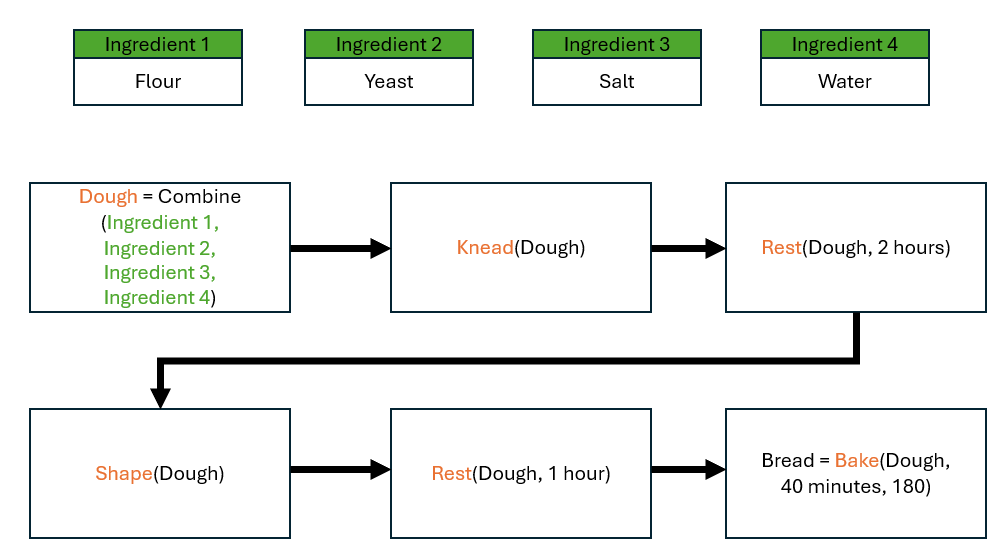

In [1]:
from IPython.display import Image, display

# This renders the file directly without loading it as a PIL object first
display(Image(filename='pictures/programming_recipe_picture1.png'))

I hope this is clear? We do not have to worry too much yet about the things that are in the boxes which define each step. Say like the step Knead(Dough) --- such a step could be called function and we will do this in the next chapter. But for now we want to focus on the **arrows** that define the flow in between. This is simply an analogy but I think a helpful one.

Say for instance you want to do the first step in the second row, Shape(Dough), but you can only do this **IF** beforehand you actually rested the dough for two hours. Have a look at the adjusted chart below. 

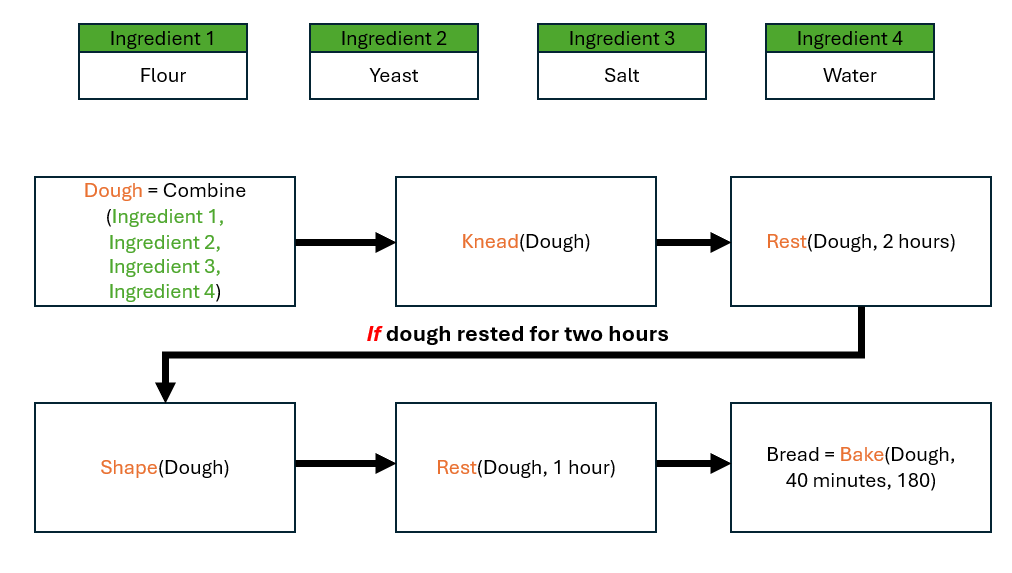

In [2]:
from IPython.display import Image, display

# This renders the file directly without loading it as a PIL object first
display(Image(filename='pictures/programming_recipe_picture2.png'))

## 1. Conditional statements: `if`, `elif`, `else`

Sometimes, you only want certain code to run *if* a condition is true.

Example — suppose we have data on per-capita energy use (in gigajoules per person):

In [3]:

energy_GJ = {
    "Switzerland": 120,
    "Austria": 150,
    "Germany": 180,
    "United States": 300,
    "India": 40,
}


We might want to categorize countries as **high**, **medium**, or **low** energy consumers:

In [4]:
country = "Austria"
energy = energy_GJ[country]

if energy > 250:
    print(country, "is a high-energy economy.")
elif energy > 100:
    print(country, "is a medium-energy economy.")
else:
    print(country, "is a low-energy economy.")

Austria is a medium-energy economy.


#### Explanation
- The `if` block runs only if the condition after `if` is true.
- The `elif` (“else if”) block tests another condition.
- The `else` block runs if none of the above conditions were met.
---

## 2. Repetition: `for` loops

In ecological-economic modeling, we often need to repeat calculations across many countries, sectors, or time steps.  
For this we use loops — the simplest is the `for` loop.

Let’s compute an estimated **energy intensity** (energy per GDP) for each country.

In [5]:
gdp_per_capita = {
    "Switzerland": 95000,
    "Austria": 70000,
    "Germany": 80000,
    "United States": 85000,
    "India": 12000,
}

for country in energy_GJ:
    ei = energy_GJ[country] / gdp_per_capita[country]
    print(country, "has energy intensity of", round(ei, 3), "GJ per $GDP")

Switzerland has energy intensity of 0.001 GJ per $GDP
Austria has energy intensity of 0.002 GJ per $GDP
Germany has energy intensity of 0.002 GJ per $GDP
United States has energy intensity of 0.004 GJ per $GDP
India has energy intensity of 0.003 GJ per $GDP


#### Explanation
- `for` iterates *over* the keys of the dictionary `energy_GJ`.
- In each iteration, `country` takes one key.
- You can perform any computation inside the loop.

---

### Looping over lists

If you had a list of countries instead:

In [6]:
countries = ["Switzerland", "Austria", "Germany", "United States", "India"]

for c in countries:
    print("Analyzing", c)

Analyzing Switzerland
Analyzing Austria
Analyzing Germany
Analyzing United States
Analyzing India


This will print each country name which is a simple but powerful idea.  
Most data analyses, even large models, boil down to loops like this.

### Looping with `range()`

Before looping over lists or dictionaries in exercises, it’s important to understand the range-for-loop. 

The keyword `range()` generates a sequence of numbers.  
By convention, Python loops count **from 0 up to (but not including)** the upper limit.

In [7]:
for i in range(5):
    print("Step", i)

Step 0
Step 1
Step 2
Step 3
Step 4


#### Explanation
- The variable `i` is the **loop index** — it takes the values `0, 1, 2, 3, 4` in turn.  
- The line inside the loop runs once for each value of `i`.  
- By default, `range(5)` means “count from 0 to 4”.

You can also specify a **start**, **stop**, and **step**:

In [8]:
for i in range(1, 11, 2):
    print("i =", i)

i = 1
i = 3
i = 5
i = 7
i = 9


Here, the loop starts at 1, stops *before* 11, and increases by 2 each time.

---

### Example: growth of energy demand

Let’s simulate the growth of energy consumption over time using a loop.

In [9]:
tpec = 100     # total primary energy consumption (EJ)
growth = 0.02  # 2% per year
years = 5

for year in range(1, years + 1):
    tpec *= (1 + growth)
    print("After year", year, "TPEC =", round(tpec, 2), "EJ")

After year 1 TPEC = 102.0 EJ
After year 2 TPEC = 104.04 EJ
After year 3 TPEC = 106.12 EJ
After year 4 TPEC = 108.24 EJ
After year 5 TPEC = 110.41 EJ



#### Explanation
- The loop variable `year` counts from 1 to 5.  
- Inside the loop, we multiply `tpec` by (1 + 0.02) each time.  
- This mimics an **iterative growth process** — the same logic used in simple economic or energy models.

---
### 🧩 Exercise: looping over multiple parameters

Imagine we want to see how **energy demand** changes under different growth rates.  
We start with a total energy consumption of 100 EJ and test several annual growth rates (from 1% to 5%). Program a for loop using range that implements this for one time step. 

In [10]:
tpec = 100  # starting value in Exajoules (EJ)

for growth in range(1, 6):   # 1%, 2%, 3%, 4%, 5%
    new_tpec = tpec * (1 + growth / 100)
    print("Growth rate:", growth, "%  →  New TPEC:", round(new_tpec, 2), "EJ")

Growth rate: 1 %  →  New TPEC: 101.0 EJ
Growth rate: 2 %  →  New TPEC: 102.0 EJ
Growth rate: 3 %  →  New TPEC: 103.0 EJ
Growth rate: 4 %  →  New TPEC: 104.0 EJ
Growth rate: 5 %  →  New TPEC: 105.0 EJ



---

## 3. While loops

`while` loops repeat **as long as** a condition is true.

Example: imagine simulating the effect of a carbon tax increasing yearly  
until emissions fall below a certain threshold.

In [11]:
emissions = 100  # MtCO2
tax_rate = 10    # $ per ton
target = 60

while emissions > target:
    emissions *= 0.95  # assume emissions fall 5% per year
    tax_rate += 2
    print(f"Tax rate: ${tax_rate}, Emissions: {round(emissions, 2)} MtCO2")

print("Target reached.")

Tax rate: $12, Emissions: 95.0 MtCO2
Tax rate: $14, Emissions: 90.25 MtCO2
Tax rate: $16, Emissions: 85.74 MtCO2
Tax rate: $18, Emissions: 81.45 MtCO2
Tax rate: $20, Emissions: 77.38 MtCO2
Tax rate: $22, Emissions: 73.51 MtCO2
Tax rate: $24, Emissions: 69.83 MtCO2
Tax rate: $26, Emissions: 66.34 MtCO2
Tax rate: $28, Emissions: 63.02 MtCO2
Tax rate: $30, Emissions: 59.87 MtCO2
Target reached.


This simulates policy adjustment — something often seen in climate policy modeling:
*if the goal is not yet reached, continue strengthening the policy.*

---

## 4. List comprehensions (short, elegant loops)

List comprehensions are a concise way to build new lists from existing data.

Suppose you want to list all **high-energy** countries (those above 150 GJ per capita):


In [12]:
high_energy = [c for c, e in energy_GJ.items() if e > 150]
print(high_energy)

['Germany', 'United States']


This one-liner does the same as a full loop like:

In [13]:
high_energy = []
for c, e in energy_GJ.items():
    if e > 150:
        high_energy.append(c)

List comprehensions are not only shorter but often more efficient —  
and they make your code more readable once you get used to them.

---

## 5. Combining `if` and loops: simple data analysis

Let’s analyze how many countries in our small dataset fall into each category.

In [14]:
high = []
medium = []
low = []

for c, e in energy_GJ.items():
    if e > 250:
        high.append(c)
    elif e > 100:
        medium.append(c)
    else:
        low.append(c)

print("High-energy:", high)
print("Medium-energy:", medium)
print("Low-energy:", low)

High-energy: ['United States']
Medium-energy: ['Switzerland', 'Austria', 'Germany']
Low-energy: ['India']


This is already a **mini data classification algorithm** —  
something often done in larger datasets, e.g., grouping countries  
by carbon intensity or by income class in input–output models.

### 🧩 Exercise

Use the dataset below to compute which countries are **above** or **below average** in energy use.

In [15]:
energy_GJ = {
    "Switzerland": 120,
    "Austria": 150,
    "Germany": 180,
    "United States": 300,
    "India": 40,
}

In [16]:

avg_energy = sum(energy_GJ.values()) / len(energy_GJ)

above = [c for c, e in energy_GJ.items() if e > avg_energy]
below = [c for c, e in energy_GJ.items() if e <= avg_energy]

print("Average energy per capita:", round(avg_energy, 1))
print("Above-average:", above)
print("Below-average:", below)

Average energy per capita: 158.0
Above-average: ['Germany', 'United States']
Below-average: ['Switzerland', 'Austria', 'India']


:::{dropdown} 💡 *Solution explanation*
- The `sum()` and `len()` functions compute the average.  
- The list comprehensions classify countries efficiently.  
- Try adding new countries to the dictionary and re-running the cell.
:::


### Summary

| Concept | Description | Example |
|----------|--------------|----------|
| `if` / `elif` / `else` | Conditional logic | classify countries by energy use |
| `for` loop | Iterate over sequences | compute energy intensity for all |
| `while` loop | Repeat while condition holds | increase carbon tax until target |
| List comprehension | Compact way to create lists | `[c for c, e in data.items() if e>150]` |

---

✅ **Key takeaway:**  
Control flow lets you tell your code *when* and *how often* to do something.  

---

### Next steps

In the next section, we’ll learn how to package these repetitive structures  
into **functions** — reusable building blocks that make your models cleaner and easier to expand.